In [15]:
%load_ext autoreload 
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


<unknown>:242: SyntaxWarning: invalid escape sequence '\P'
<unknown>:242: SyntaxWarning: invalid escape sequence '\P'


Importation of our class from other files 

In [16]:
from Main_functions import Potential_extraction
from Main_functions import Generation_quad
from Main_functions import Data_exploitation
from Main_functions import SimulationParaxiale
from Main_functions import Data_exploitation_whitoutfit
from Main_functions import Data_exploitation_1982
from Extraction_data import Extracted_data
from okayama_quad import Okayama_quad
from Multipolar_decomposition import Decomposition
from Fit_functions import Fit_constants
from paraxial import Ion
import numpy as np
from aberration import Aberration



In [17]:
Va = 2000
tension1 = {
    "va1":  0.018808 * Va,   # Tension Aperture 10.18808
    "va2": -0.018808 * Va,    # Tension Aperture 2
    "vq13": 0.0299087 * Va,    # Tension Quad 1&3
    "vq24": -0.0299087 * Va,      #tension quad 2 et 4        
    "vaAc": Va,               # Tension acceleation
}
tension = {
    "va1":  1 * Va,   # Tension Aperture 10.18808
    "va2": -1 * Va,    # Tension Aperture 2
    "vq13": 1* Va,    # Tension Quad 1&3
    "vq24": -1 * Va,      #tension quad 2 et 4        
    "vaAc": Va,               # Tension acceleation
}
out_dir = "Files1982"

In [18]:
quad = Generation_quad(tension, out_dir)
file_path_quad = quad.reconstr()

Fichier reconstruit sauvegardé : Files1982\quad_reconstuit.npz


In [19]:

#files with our potential data
file_path = r"C:\Users\llamm\OneDrive\Documents\Projet\BEMPP\okayama\projet_multi\projet-multi-code\Quadrupole_model\Files\potentiel_quadrupole_VF1.npz"

file_pathl = r"projet-multi-code\Quadrupole_model\Files\potentiel_quadrupole_VF.npz"


2.61


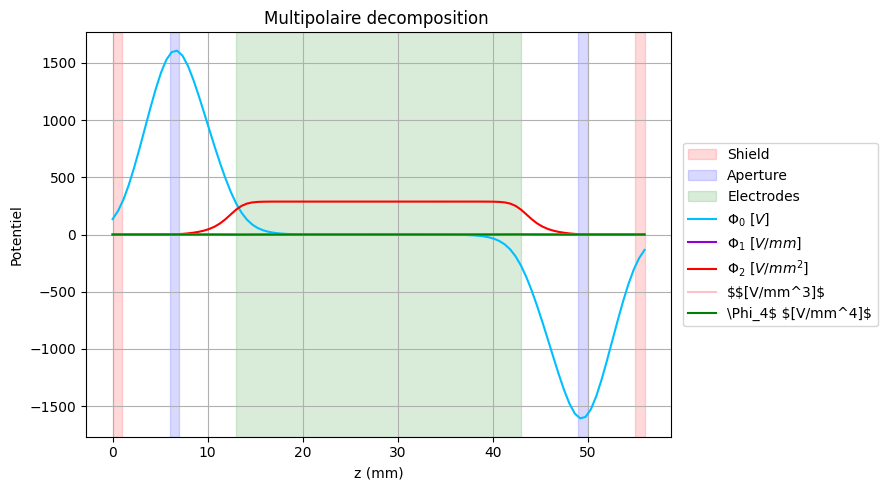

valeur theroqie de phi2 max Vq/a2 = 2000
valeur de phi2 max 287.8705956926166


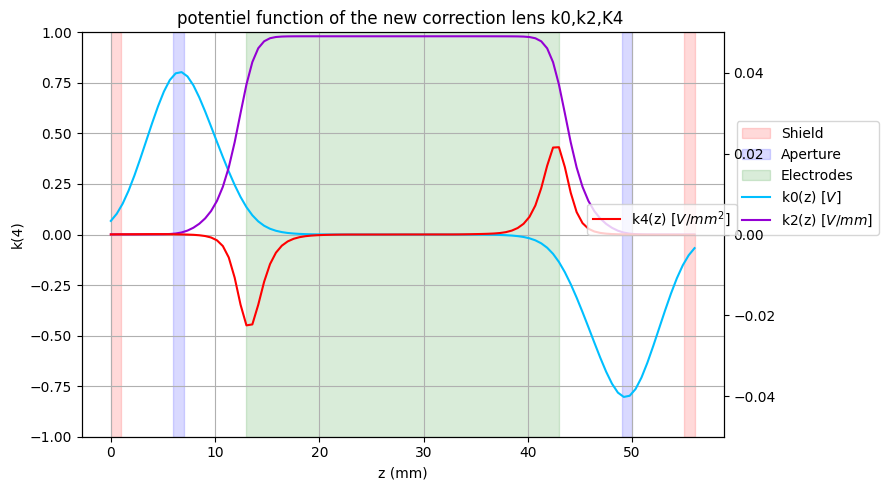

In [20]:
extracted_data = Extracted_data(file_path_quad) 
print(extracted_data.radius_axis)
extracted_data.derivative()

fun = Data_exploitation_1982(extracted_data)
fun.decomposition_calculation()
fun.decomposition_graph()

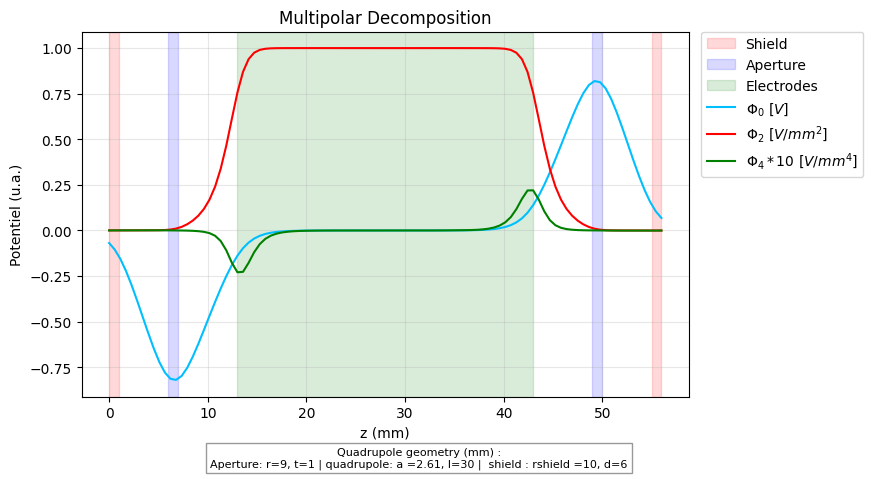

In [21]:

fun.fit_graph()

Trajectoire Paraxiale

In [22]:
n = 100
e = -1.6e-19

marginal = Ion(1.6e-27, e, "principal", 0, 0.01, 0, 0.01)
principal = Ion(1.6e-27, e, "marginal", 1, 0, 1, 0)

marginalc = Ion(1.6e-27, e, "marginal", 0, 0.01, 0, 0.01)
principalc = Ion(1.6e-27, e, "principal", 1, 0, 1, 0)

Trajectoire = SimulationParaxiale(extracted_data, Decomp)
Trajectoire.run_discret(marginal, principal)

Trajectoire.run_convergence(marginalc, principalc, n)


NameError: name 'Decomp' is not defined

2000
2000
2000
2000
2000


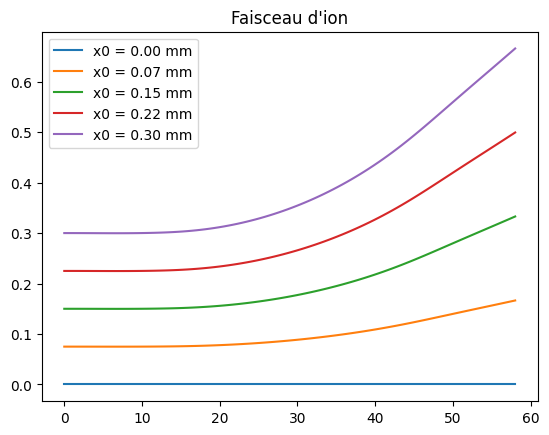

In [ ]:

#faisceau
liste = []

#n nombre d'ion que l'on veut 
nb = 5

positions_initiales = np.linspace(0, 0.3, nb)
for i in positions_initiales:
    ion= Ion(1.6e-27, e, f"Ion_{i:.1f}", i, 0.00, i, 0.00)
    liste.append(ion)


Trajectoire.run_faisceau(liste)

Tout le systeme d'okayama

In [ ]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
#quad en entiers
Va = 2000 

tension_quad1 = {
    "va1":  0,   # Tension Aperture 1
    "va2": 0,    # Tension Aperture 2
    "vq13": 0.030872 * Va,    # Tension Quad 1&3
    "vq24": -0.030872* Va,      #tension quad 2 et 4        
    "vaAc": Va,               # Tension acceleation
}

#8 mm
tension_quad2= {
    "va1": - 0.188084 * Va,   # Tension Aperture 1
    "va2": 0.109177 * Va,    # Tension Aperture 2
    "vq13": -0.029909 * Va,    # Tension Quad 1&3
    "vq24": 0.029909 * Va,      #tension quad 2 et 4        
    "vaAc": Va,               # Tension acceleation
}
#21 mm
tension_quad3= {
    "va1":  0.109177 * Va,   # Tension Aperture 1
    "va2": -0.188084 * Va,    # Tension Aperture 2
    "vq13": 0.029909 * Va,    # Tension Quad 1&3
    "vq24": -0.029909 * Va,      #tension quad 2 et 4        
    "vaAc": Va,               # Tension acceleation
}

#8mm
tension_quad4= {
    "va1":  0,   # Tension Aperture 1
    "va2": 0,# Tension Aperture 2
    "vq13": -0.030872 * Va,    # Tension Quad 1&3
    "vq24": 0.030872 * Va,      #tension quad 2 et 4        
    "vaAc": Va,               # Tension acceleation
}

Liste_tension =[tension_quad1, tension_quad2, tension_quad3, tension_quad4]
#Liste_z = [0, 34,82, 113]

Liste_z = [0, 36.8, 80.2, 117]
#Liste_z = [0,37,90.5,127.5]
out_dir = "Files1982"


In [ ]:
okayama = Okayama_quad(out_dir, Liste_z, Liste_tension)
Okayama_path = okayama.save("okayama_quad.npz")

 Fichier sauvegardé pour Extracted_data : Files1982\okayama_quad.npz


In [ ]:
extracted_data2 = Extracted_data(Okayama_path,Liste_z ) 
extracted_data2.derivative()
extracted_data2.position_quad()
Decomp2= Decomposition(extracted_data2)
quad_ent = Data_exploitation_whitoutfit(extracted_data2)
Decomp2.composantes()

[0, 36.8, 80.2, 117]


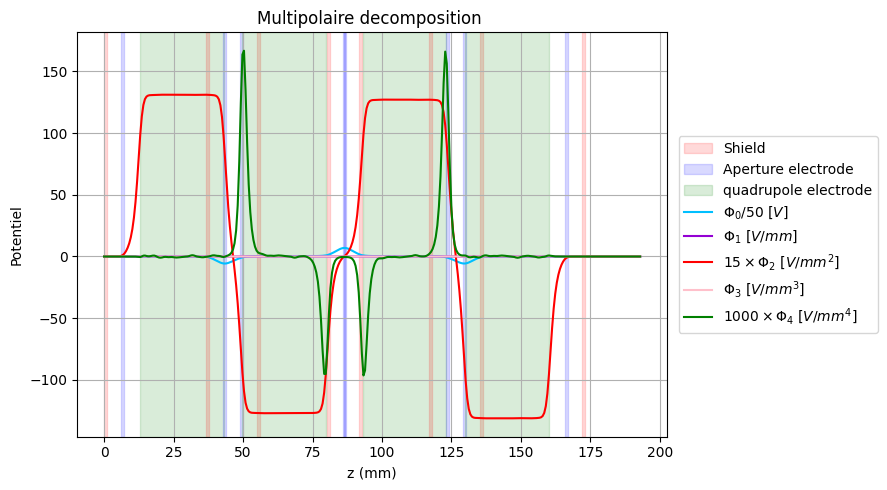

[0, 36.8, 80.2, 117]


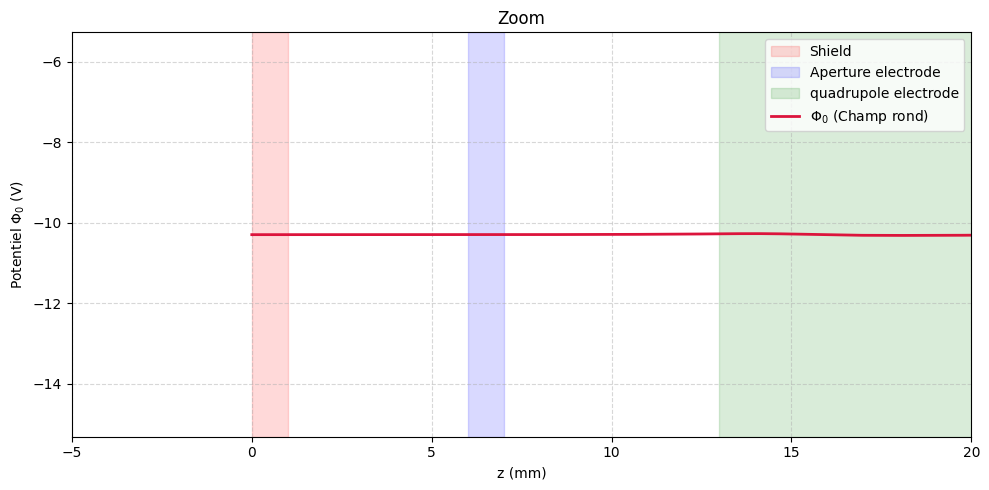

In [ ]:
quad_ent.decomposition_calculation()
quad_ent.decomposition_graph()

2000
2000


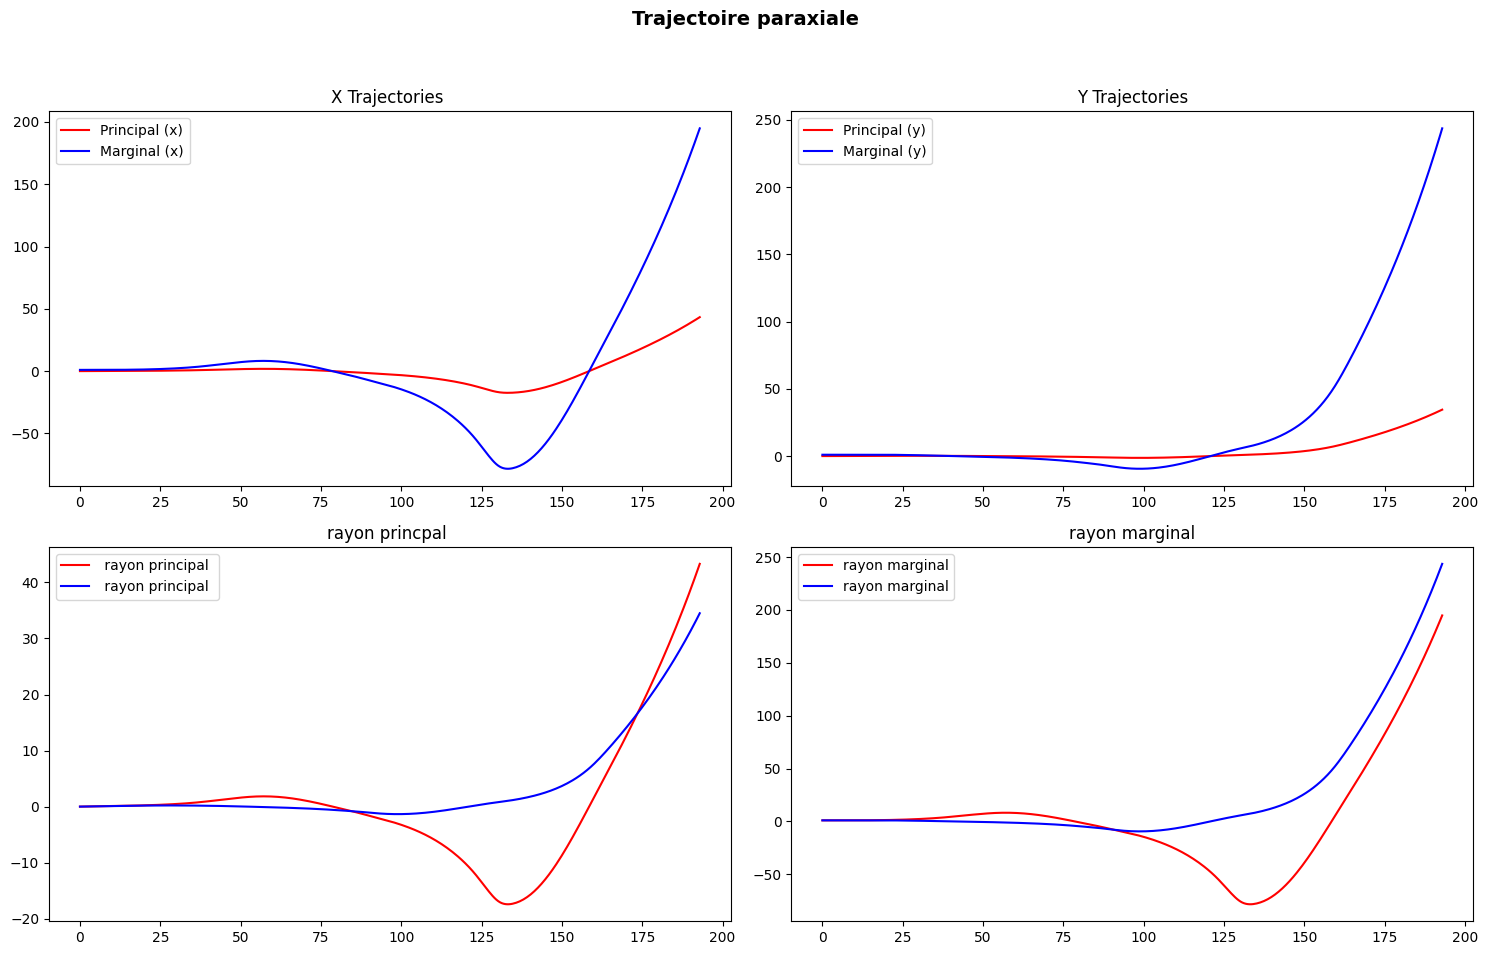

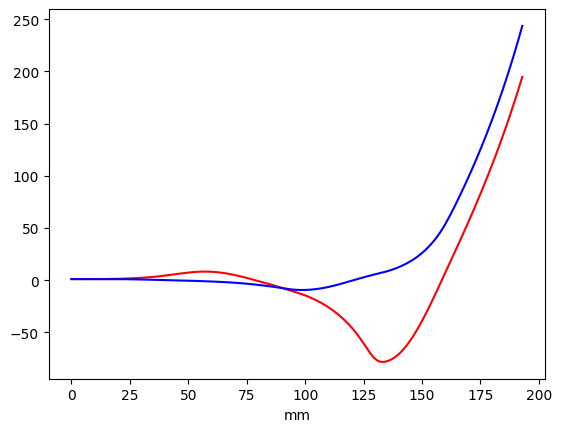

AttributeError: 'Decomposition' object has no attribute 'P'

In [ ]:
n = 100
e = -1.6e-19

marginal = Ion(1.6e-27, e, "principal", 0, 0.01, 0, 0.01)
principal = Ion(1.6e-27, e, "marginal", 1, 0, 1, 0)

marginalc = Ion(1.6e-27, e, "marginal", 0, 0.01, 0, 0.01)
principalc = Ion(1.6e-27, e, "principal", 1, 0, 1, 0)

Trajectoire = SimulationParaxiale(extracted_data2, Decomp2)
Trajectoire.run_discret(marginal, principal)

abberation = Aberration()
c = abberation.coefficient(marginal, Decomp2 )
print("coefficient d'abberation", c)




Fichier reconstruit sauvegardé : files\quad_reconstuit.npz


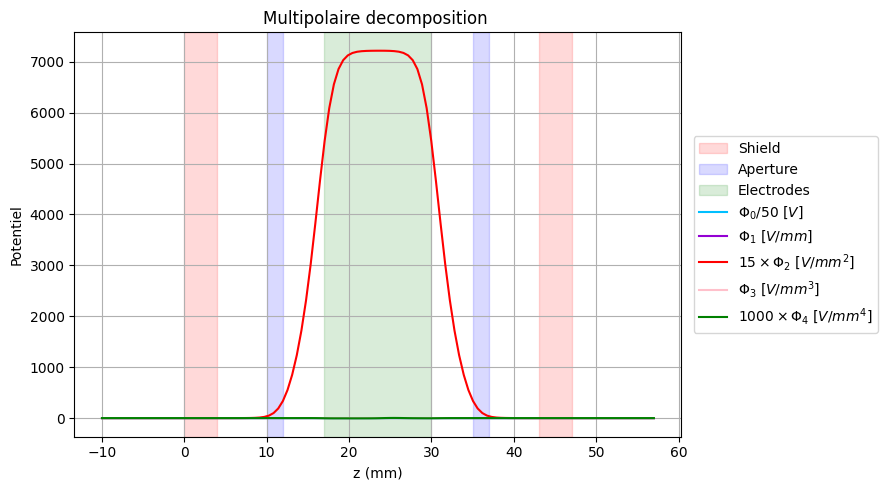

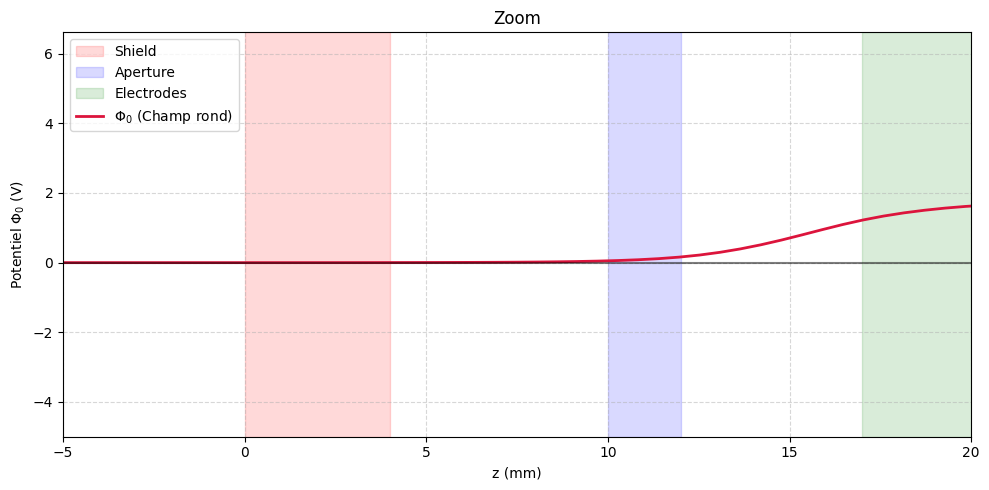

In [ ]:
Va = 200000
tension_uni = {
    "va1":  0.0 * Va,   # Tension Aperture 1
    "va2": 0 * Va,    # Tension Aperture 2
    "vq13": 0.0299087 * Va,    # Tension Quad 1&3
    "vq24": -0.0299087 * Va,      #tension quad 2 et 4        
    "vaAc": Va,               # Tension acceleation
}
out_dir = "files"

quadunit = Generation_quad(tension_uni, out_dir)
file_path_unit = quadunit.reconstr()

extracted_data_uni = Extracted_data(file_path_unit) 
extracted_data_uni.derivative()

Decomp_unit= Decomposition(extracted_data)
Decomp_unit.composantes()

fun2= Data_exploitation(extracted_data_uni, None)
fun2.decomposition_calculation()
fun2.decomposition_graph()

#

200000
200000


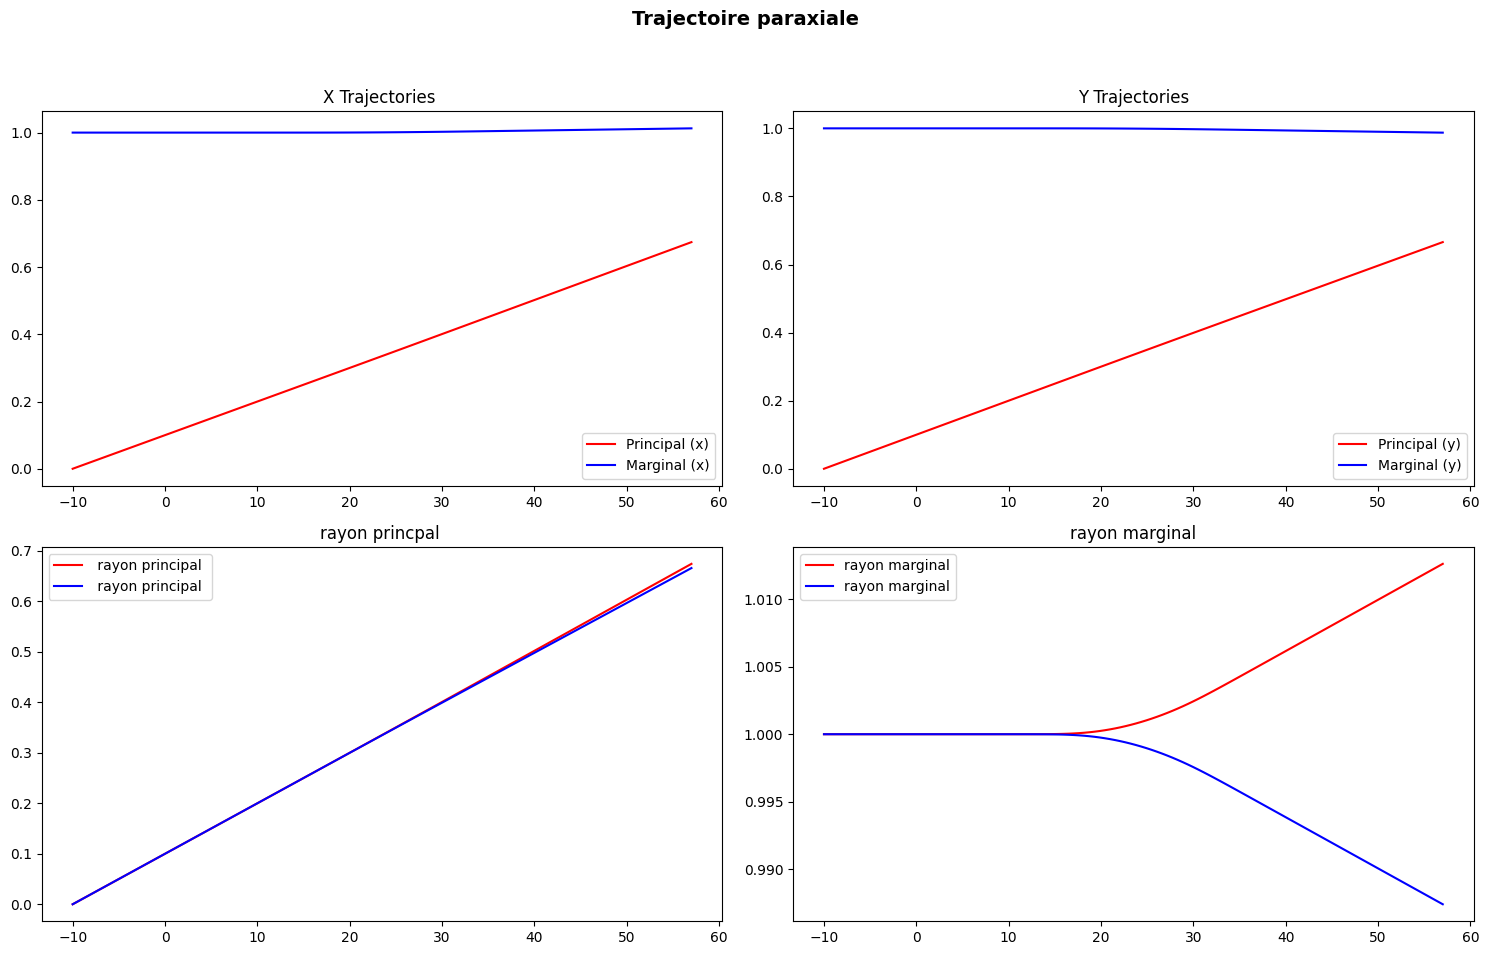

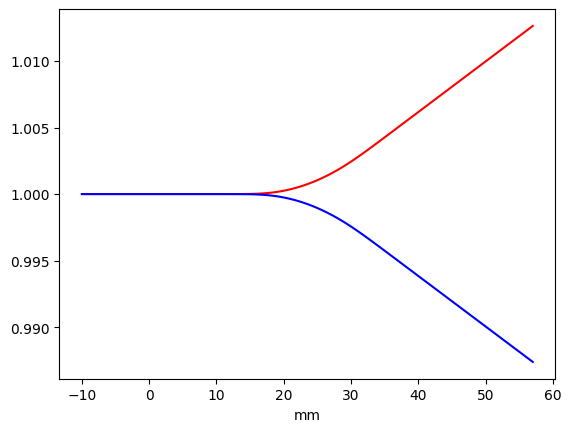

<bound method SimulationParaxiale.plot_theo of <Main_functions.SimulationParaxiale object at 0x00000220F6FB15B0>>

In [ ]:
n = 100
e = -1.6e-19

marginal = Ion(1.6e-27, e, "principal", 0, 0.01, 0, 0.01)
principal = Ion(1.6e-27, e, "marginal", 1, 0, 1, 0)



Trajectoire_uni = SimulationParaxiale(extracted_data_uni, Decomp_unit)
Trajectoire_uni.run_discret(marginal, principal)
Trajectoire_uni.plot_theo
